In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('../data/online_retail_customer_churn.csv')

In [3]:
df

,Customer_ID,Age,Gender,Annual_Income,Total_Spend,Years_as_Customer,Num_of_Purchases,Average_Transaction_Amount,Num_of_Returns,Num_of_Support_Contacts,Satisfaction_Score,Last_Purchase_Days_Ago,Email_Opt_In,Promotion_Response,Target_Churn
0,1,62,Other,45.15,5892.58,5,22,453.80,2,0,3,129,True,Responded,True
1,2,65,Male,79.51,9025.47,13,77,22.90,2,2,3,227,False,Responded,False
2,3,18,Male,29.19,618.83,13,71,50.53,5,2,2,283,False,Responded,True
3,4,21,Other,79.63,9110.30,3,33,411.83,5,3,5,226,True,Ignored,True
4,5,21,Other,77.66,5390.88,15,43,101.19,3,0,5,242,False,Unsubscribed,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,54,Male,143.72,1089.09,2,29,77.75,0,3,2,88,True,Ignored,False
996,997,19,Male,164.19,3700.24,9,90,34.45,6,4,4,352,False,Responded,True
997,998,47,Female,113.31,705.85,17,69,187.37,7,3,1,172,True,Unsubscribed,False
998,999,23,Male,72.98,3891.60,7,31,483.80,1,2,5,55,False,Responded,True


In [4]:
df.isnull().sum()

Customer_ID                   0
Age                           0
Gender                        0
Annual_Income                 0
Total_Spend                   0
Years_as_Customer             0
Num_of_Purchases              0
Average_Transaction_Amount    0
Num_of_Returns                0
Num_of_Support_Contacts       0
Satisfaction_Score            0
Last_Purchase_Days_Ago        0
Email_Opt_In                  0
Promotion_Response            0
Target_Churn                  0
dtype: int64

In [5]:
df.dtypes

Customer_ID                     int64
Age                             int64
Gender                            str
Annual_Income                 float64
Total_Spend                   float64
Years_as_Customer               int64
Num_of_Purchases                int64
Average_Transaction_Amount    float64
Num_of_Returns                  int64
Num_of_Support_Contacts         int64
Satisfaction_Score              int64
Last_Purchase_Days_Ago          int64
Email_Opt_In                     bool
Promotion_Response                str
Target_Churn                     bool
dtype: object

In [6]:
print(f"different ages - {df['Age'].unique()}")
print(f"days since last purchased - {df['Last_Purchase_Days_Ago'].unique()}")
print(f" max no of days ago - {max(df['Last_Purchase_Days_Ago'])}\n min no of days ago - {min(df['Last_Purchase_Days_Ago'])}")

different ages - [62 65 18 21 57 27 37 39 68 54 41 24 42 30 19 56 64 35 55 43 31 26 38 69
 34 23 33 36 53 67 47 32 50 49 28 29 46 52 58 22 59 60 45 66 48 61 20 40
 44 63 51 25]
days since last purchased - [129 227 283 226 242 130  61 224 126 171  92 213 276 212 125 304 274 197
   4  57 323 199 193 119  35 352 317 128  31 325 253 196 188 102 216 260
 360 263 202 273 121  84 277 234 322 287 168  86 110  37  21 108 209 251
  65 137 105 261 259 262 307 182  42 138 267 284 104 162  85   8 219  87
 112 303 240 111 269 340  23 335 207 223 278 147 353  82 266  95 173 144
 255 195 169 145  78 150 332  58  38 203 362 190 359  50 326 337 245 179
 208 296  27  30 140 231 254 236  49 120  52 338 319   5 114 148 339 331
 222 201 127  99 214 239   6  69  40 250 165 175 205 206 174  41 106 185
 348 324  43 204 122 342 101  53 237 232  14 191  76 341 268 136 157 358
 282 217  74 252 349 293 221  44  10 164   7 297 264  28 298 320 347 229
 294  97 314 295  89 133  75 218 310 176  90 131 364   2 265 311 

In [7]:
df['age_group']=np.select([((df['Age']>0) & (df['Age']<25)),
                         ((df['Age']>=25) & (df['Age']<50)),
                         ((df['Age']>=50) & (df['Age']<75))],
                         ["0-24","25-49","50-74"],
                         default="above 75")


In [8]:
months=(df['Last_Purchase_Days_Ago']/30.44).round(0).astype('int')

In [9]:
df['months_since']=months.astype('str')+ " months ago"
df.loc[months==0,'months_since']="last month"

In [10]:
df.drop(['Age','Last_Purchase_Days_Ago','Customer_ID'],axis=1,inplace=True)

In [11]:
df['Annual_Income']=df['Annual_Income'].apply(lambda x:x*1000)

In [12]:
max(df['Num_of_Purchases']), min(df['Num_of_Purchases'])

(99, 1)

In [13]:
def bar_labels(ax:int):
    for container in ax.containers:
        ax.bar_label(container, padding=3)

In [16]:
df

,Gender,Annual_Income,Total_Spend,Years_as_Customer,Num_of_Purchases,Average_Transaction_Amount,Num_of_Returns,Num_of_Support_Contacts,Satisfaction_Score,Email_Opt_In,Promotion_Response,Target_Churn,age_group,months_since
0,Other,45150.0,5892.58,5,22,453.80,2,0,3,True,Responded,True,50-74,4 months ago
1,Male,79510.0,9025.47,13,77,22.90,2,2,3,False,Responded,False,50-74,7 months ago
2,Male,29190.0,618.83,13,71,50.53,5,2,2,False,Responded,True,0-24,9 months ago
3,Other,79630.0,9110.30,3,33,411.83,5,3,5,True,Ignored,True,0-24,7 months ago
4,Other,77660.0,5390.88,15,43,101.19,3,0,5,False,Unsubscribed,False,0-24,8 months ago
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Male,143720.0,1089.09,2,29,77.75,0,3,2,True,Ignored,False,50-74,3 months ago
996,Male,164190.0,3700.24,9,90,34.45,6,4,4,False,Responded,True,0-24,12 months ago
997,Female,113310.0,705.85,17,69,187.37,7,3,1,True,Unsubscribed,False,25-49,6 months ago
998,Male,72980.0,3891.60,7,31,483.80,1,2,5,False,Responded,True,0-24,2 months ago


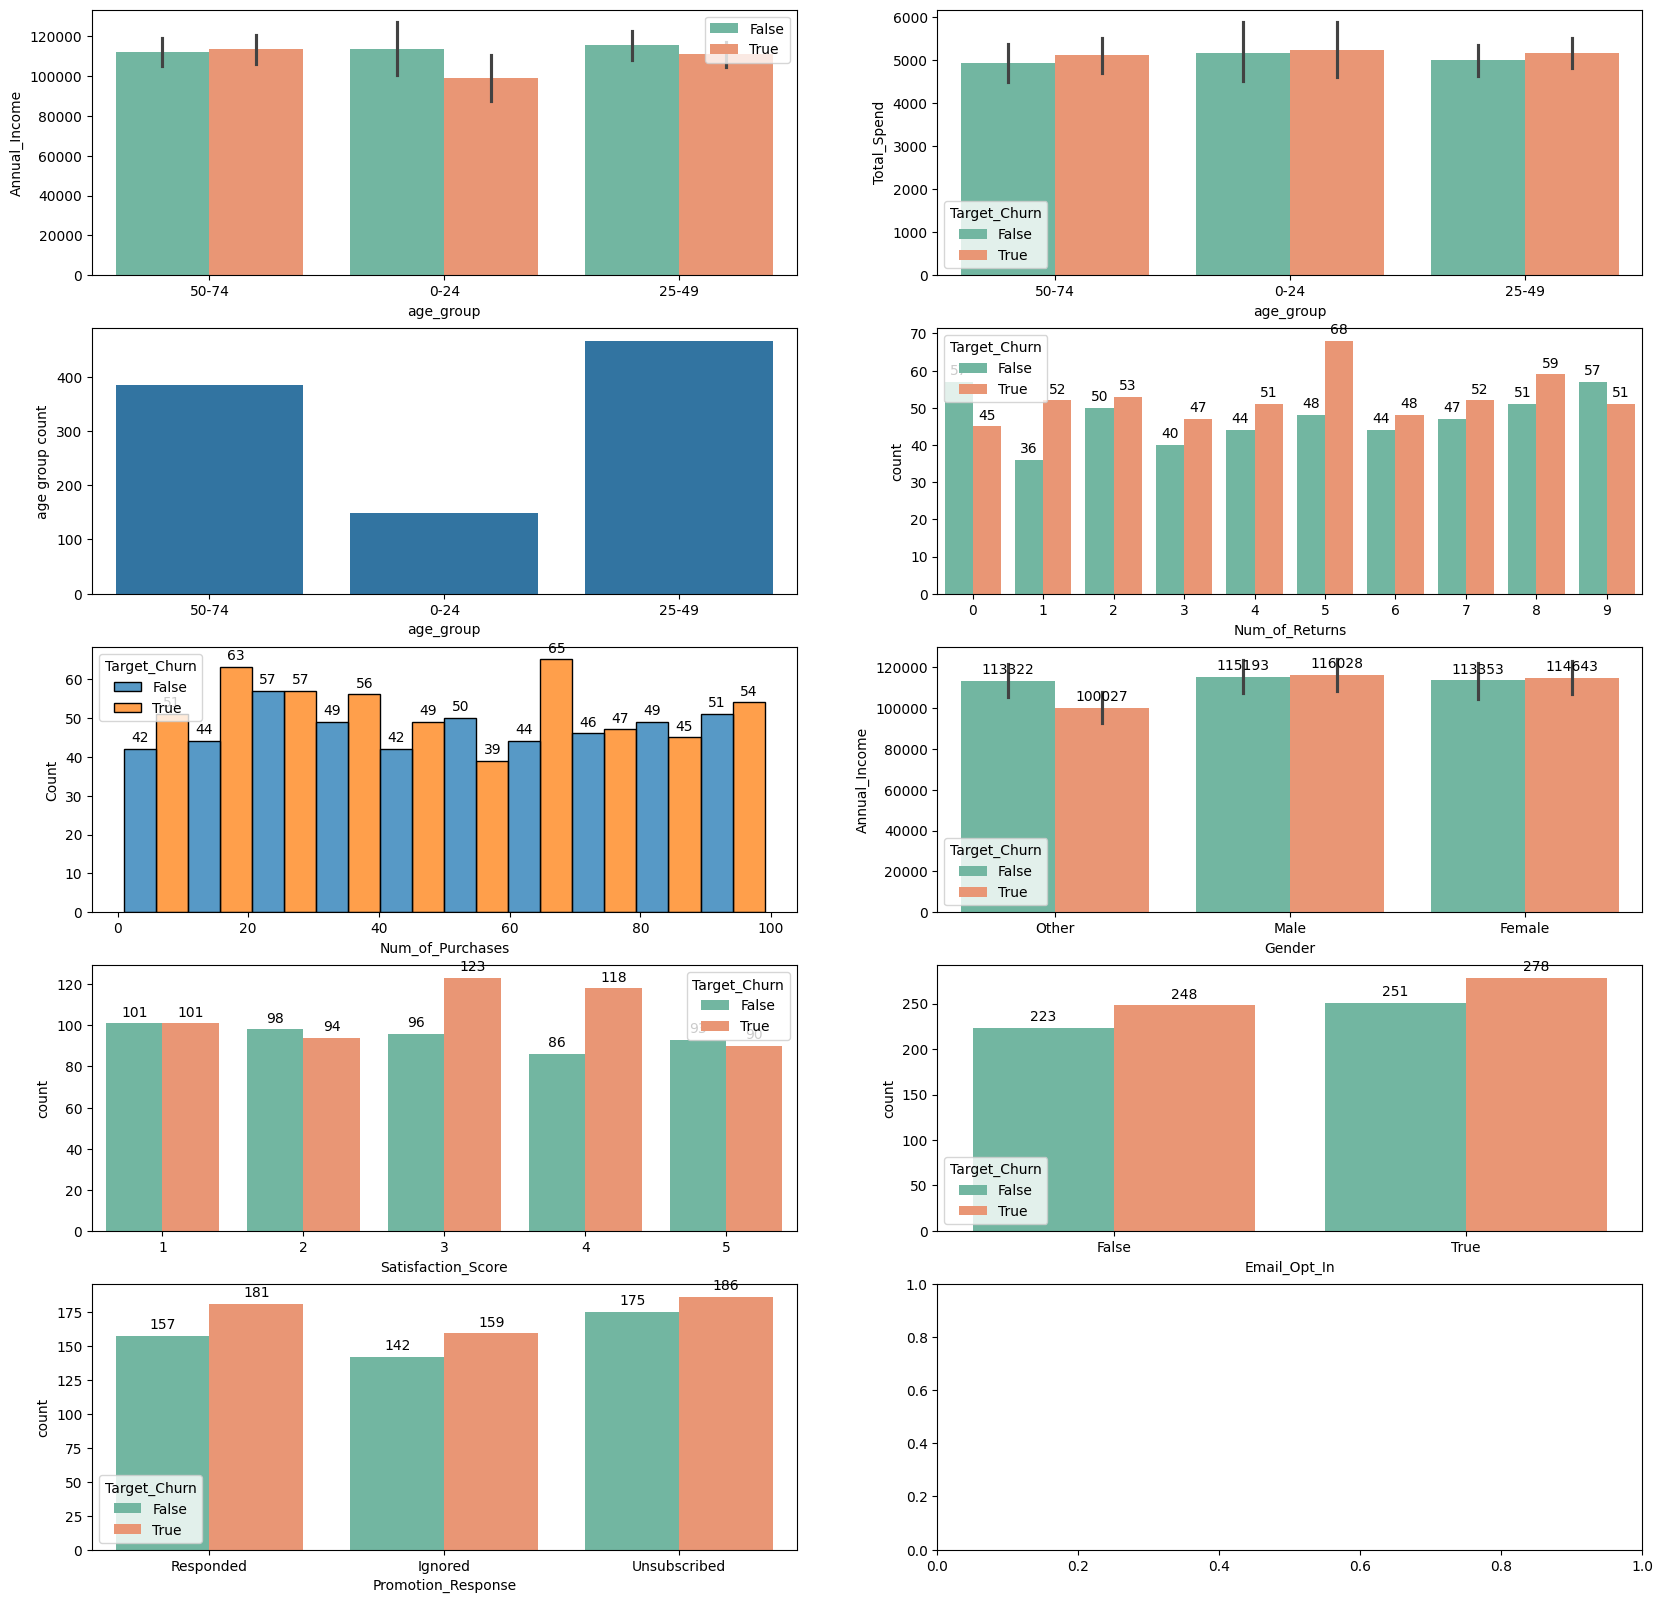

In [19]:
fig,axes=plt.subplots(nrows=5,ncols=2,figsize=(20,20))
ax=axes.flat
sns.barplot(data=df,x='age_group',y='Annual_Income',hue='Target_Churn',palette='Set2',estimator=np.mean,ax=ax[0])
ax[0].legend(loc='upper right')
sns.barplot(data=df,x='age_group',y='Total_Spend',hue='Target_Churn',palette='Set2',estimator=np.mean,ax=ax[1])
sns.countplot(data=df,x='age_group',ax=ax[2])
ax[2].set_ylabel('age group count')
sns.countplot(data=df,x='Num_of_Returns',hue='Target_Churn',palette='Set2',ax=ax[3])
bar_labels(ax[3])
sns.barplot(data=df,x='Gender',y='Annual_Income',hue='Target_Churn',palette='Set2',estimator=np.mean,ax=ax[5])
bar_labels(ax[5])
sns.histplot(data=df,x='Num_of_Purchases',hue='Target_Churn',bins=10,ax=ax[4],multiple='dodge')
bar_labels(ax[4])
sns.countplot(data=df,x='Satisfaction_Score',hue='Target_Churn',palette='Set2',ax=ax[6])
bar_labels(ax[6])
sns.countplot(data=df,x='Email_Opt_In',hue='Target_Churn',palette='Set2',ax=ax[7])
bar_labels(ax[7])
sns.countplot(data=df,x='Promotion_Response',hue='Target_Churn',palette='Set2',ax=ax[8])
bar_labels(ax[8])




In [ ]:
colors = [ '#4DFFB5','#FF4D6D']
churn = df['Target_Churn'].value_counts()
churn.plot(kind = 'pie', figsize = (4,4), colors=colors, autopct='%1.1f%%')
plt.title('Plot of Target Churn')